# NLP Project — Arabic Hotel Reviews

**Goal:** Classify Arabic hotel reviews as Positive or Negative.

**Dataset:** HARD (Hotel Arabic Reviews Dataset) from Git Hub

**Models:**
- Logistic Regression + TF-IDF
- Bidirectional LSTM

In [35]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

## 📥 Load Dataset

In [36]:
df = pd.read_csv(
    'Hotel-Arabic-Reviews-Dataset.csv',
    encoding='cp1256',
    engine='python',
    on_bad_lines='skip'
)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105698 entries, 0 to 105697
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   no          105698 non-null  int64 
 1   Hotel name  105698 non-null  object
 2   rating      105698 non-null  int64 
 3   user type   105698 non-null  object
 4   room type   105698 non-null  object
 5   nights      105698 non-null  object
 6   review      105698 non-null  object
dtypes: int64(2), object(5)
memory usage: 5.6+ MB


## 🔧 Preprocessing
Steps applied:
- Remove Latin characters and digits
- Remove Arabic diacritics (tashkeel)
- Normalize letters (إ أ آ → ا, ة → ه, ى → ي)
- Remove punctuation and extra spaces
- Remove Arabic stopwords


In [37]:
ARABIC_STOPWORDS = set("""
في من على إلى عن مع هذا هذه ذلك تلك هو هي هم هن نحن انا انت
كان كانت يكون تكون كنت كنا قد لقد ما لا لم لن بل أو او ثم
كل بعض غير مثل عند لدى حيث كما إذا اذا لكن لكي حتى
يا أي اي و ف ب ل ك التي الذي الذين اللاتي اللواتي
""".split())

def preprocess_arabic(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[a-zA-Z0-9]', '', text)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    text = re.sub(r'[إأآ]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ـ', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in ARABIC_STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

df = df[df['rating'] != 3].copy()
df['sentiment'] = df['rating'].apply(lambda r: 1 if r >= 4 else 0)
df['clean_review'] = df['review'].apply(preprocess_arabic)
df = df[df['clean_review'].str.len() > 0].reset_index(drop=True)

print("Final dataset size:", len(df))
print(df['sentiment'].value_counts())

Final dataset size: 105645
sentiment
0    52824
1    52821
Name: count, dtype: int64


## 📊 Class Distribution

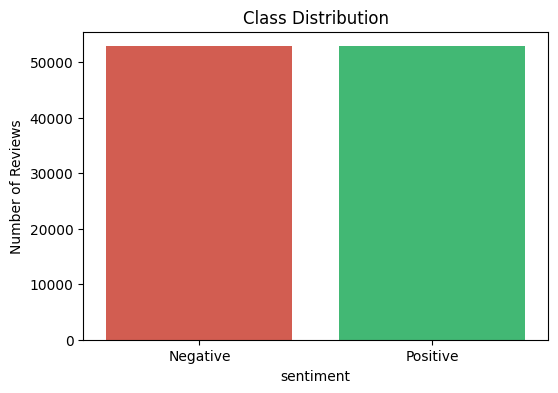

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette=['#e74c3c', '#2ecc71'])
plt.xticks([0,1], ['Negative', 'Positive'])
plt.title('Class Distribution')
plt.ylabel('Number of Reviews')
plt.show()

## ✂️ Train / Test Split

In [39]:
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 84516
Test size : 21129


## 🤖 Model 1 – Machine Learning (Logistic Regression + TF-IDF)
A traditional ML baseline using TF-IDF features with unigrams and bigrams.


In [40]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print("Vocabulary size:", len(tfidf.vocabulary_))

Vocabulary size: 20000


In [41]:
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_vec, y_train)

lr_pred = lr.predict(X_test_vec)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1  = f1_score(y_test, lr_pred, average='weighted')

print(f"Accuracy : {lr_acc:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['Negative','Positive']))

Accuracy : 0.8452
F1 Score : 0.8452

              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84     10565
    Positive       0.84      0.85      0.85     10564

    accuracy                           0.85     21129
   macro avg       0.85      0.85      0.85     21129
weighted avg       0.85      0.85      0.85     21129



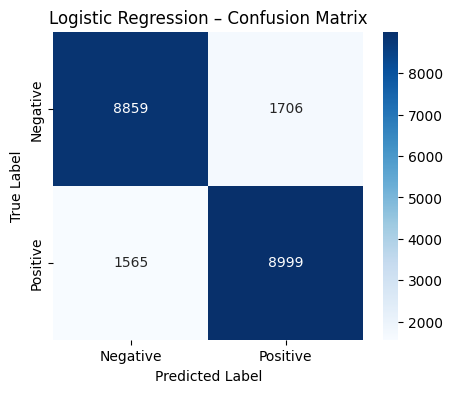

In [42]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Logistic Regression – Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 🤖 Model 2 – Deep Learning (LSTM)
A Bidirectional LSTM network with an embedding layer, trained on tokenized sequences.


In [43]:
# Tokenize text into integer sequences
MAX_VOCAB = 20000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Train shape:", X_train_pad.shape)
print("Test shape :", X_test_pad.shape)

Train shape: (84516, 100)
Test shape : (21129, 100)


In [44]:
# Build LSTM model
EMBED_DIM = 64

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train.values,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7951 - loss: 0.4094 - val_accuracy: 0.8242 - val_loss: 0.3572
Epoch 2/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8253 - loss: 0.3574 - val_accuracy: 0.8276 - val_loss: 0.3506
Epoch 3/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8339 - loss: 0.3441 - val_accuracy: 0.8293 - val_loss: 0.3465
Epoch 4/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8405 - loss: 0.3332 - val_accuracy: 0.8340 - val_loss: 0.3411
Epoch 5/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8463 - loss: 0.3233 - val_accuracy: 0.8370 - val_loss: 0.3387


In [46]:
# Evaluate LSTM
lstm_probs = model.predict(X_test_pad, verbose=0).ravel()
lstm_pred  = (lstm_probs >= 0.5).astype(int)

lstm_acc = accuracy_score(y_test, lstm_pred)
lstm_f1  = f1_score(y_test, lstm_pred, average='weighted')

print(f"Accuracy : {lstm_acc:.4f}")
print(f"F1 Score : {lstm_f1:.4f}")
print()
print(classification_report(y_test, lstm_pred, target_names=['Negative','Positive']))

Accuracy : 0.8302
F1 Score : 0.8295

              precision    recall  f1-score   support

    Negative       0.88      0.77      0.82     10565
    Positive       0.79      0.89      0.84     10564

    accuracy                           0.83     21129
   macro avg       0.84      0.83      0.83     21129
weighted avg       0.84      0.83      0.83     21129



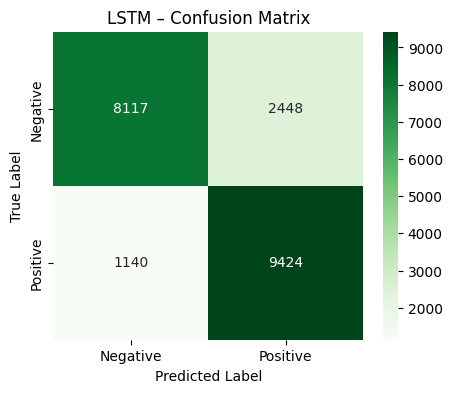

In [47]:
# Confusion matrix for LSTM
cm_lstm = confusion_matrix(y_test, lstm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('LSTM – Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

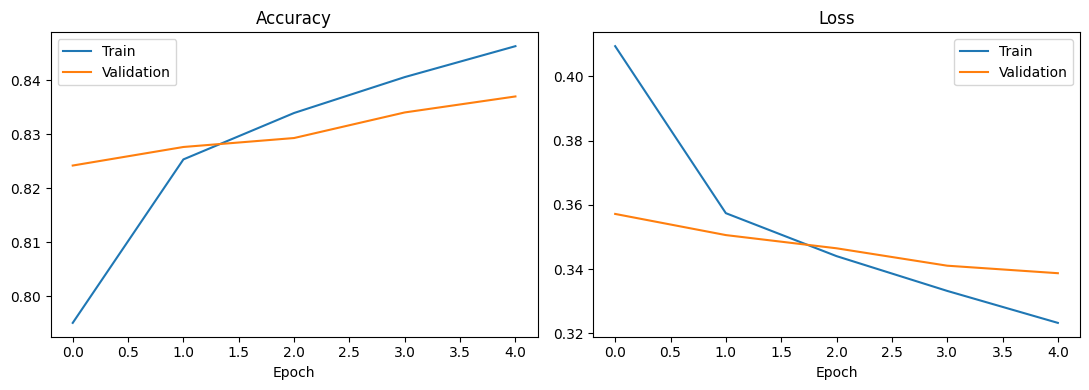

In [48]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## 📊 Comparison of the Two Approaches

In [49]:
results = pd.DataFrame({
    'Model'   : ['Logistic Regression (ML)', 'LSTM (Deep Learning)'],
    'Accuracy': [lr_acc, lstm_acc],
    'F1 Score': [lr_f1,  lstm_f1]
})
print(results.to_string(index=False))

                   Model  Accuracy  F1 Score
Logistic Regression (ML)  0.845189  0.845182
    LSTM (Deep Learning)  0.830186  0.829533


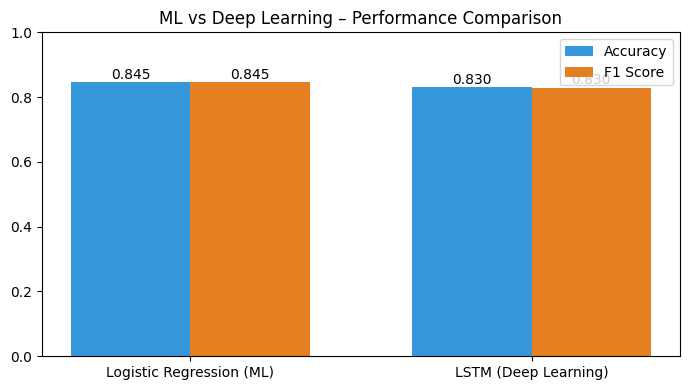

In [50]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(results))
width = 0.35

ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x + width/2, results['F1 Score'], width, label='F1 Score', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1)
ax.set_title('ML vs Deep Learning – Performance Comparison')
ax.legend()
for i, (a, f) in enumerate(zip(results['Accuracy'], results['F1 Score'])):
    ax.text(i - width/2, a + 0.01, f"{a:.3f}", ha='center')
    ax.text(i + width/2, f + 0.01, f"{f:.3f}", ha='center')
plt.tight_layout()
plt.show()